# 01 — Exact Model

Build the 3-state Bragg Hamiltonian, diagonalize it exactly with NumPy, and characterize the avoided crossings near $\delta = \pm 4$.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from src.hamiltonian import bragg_hamiltonian
from src.exact_solver import eigenspectrum, ground_state, ground_state_populations, minimum_gap

In [2]:
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "#0b1020",
    "axes.facecolor": "#0b1020",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#cbd5e1",
    "ytick.color": "#cbd5e1",
    "text.color": "#e2e8f0",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "axes.grid": True,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

## Sanity check

The Hamiltonian must be Hermitian for every $(\delta, \Omega)$.

In [3]:
H = bragg_hamiltonian(delta=0, omega=0.5)
print("Hermitian:", np.allclose(H, H.conj().T))

Hermitian: True


In [4]:
ground_energy, ground_vector = ground_state(delta=0.0, omega=0.5)
print("Exact ground energy:", ground_energy)
print("Exact ground state:", ground_vector)

Exact ground energy: -0.12132034355964301
Exact ground state: [-0.11957316  0.98559856 -0.11957316]


## Eigenspectrum vs detuning

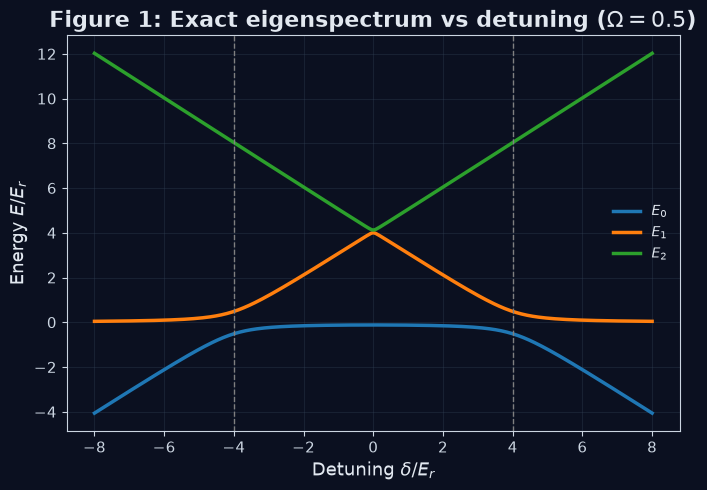

In [5]:
delta_values = np.linspace(-8, 8, 300)
omega = 0.5

energies = eigenspectrum(delta_values, omega=omega)

fig, ax = plt.subplots(figsize=(7, 5))
for level in range(3):
    ax.plot(delta_values, energies[:, level], label=f"$E_{level}$")

ax.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax.axvline(4, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"Detuning $\delta / E_r$")
ax.set_ylabel(r"Energy $E / E_r$")
ax.set_title(rf"Figure 1: Exact eigenspectrum vs detuning ($\Omega = {omega}$)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/fig1_exact_eigenspectrum.png", dpi=150, bbox_inches="tight")
plt.show()

## Ground-state momentum populations vs detuning

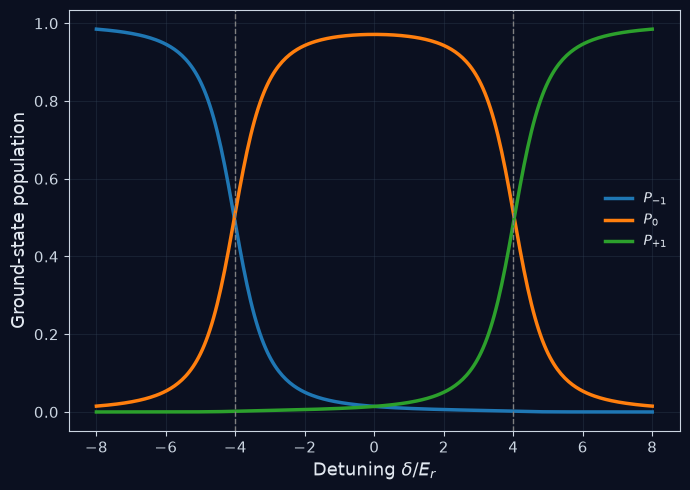

In [6]:
population_data = ground_state_populations(delta_values, omega=omega)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(delta_values, population_data[:, 0], label=r"$P_{-1}$")
ax.plot(delta_values, population_data[:, 1], label=r"$P_0$")
ax.plot(delta_values, population_data[:, 2], label=r"$P_{+1}$")

ax.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax.axvline(4, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"Detuning $\delta / E_r$")
ax.set_ylabel("Ground-state population")
ax.legend()
fig.tight_layout()
plt.show()

## Minimum avoided-crossing gap vs $\Omega$

Near $\delta = 4$, $|0\rangle$ and $|{+1}\rangle$ hybridize; the two-level avoided crossing predicts a minimum gap of $2\Omega$.

In [7]:
omega_values = [0.05, 0.1, 0.2, 0.5]
window_deltas = np.linspace(3.0, 5.0, 2001)

min_gaps = [minimum_gap(window_deltas, omega=w) for w in omega_values]

print(f"{'Omega':^12} {'gap_min':^18} {'2*Omega':^15} {'rel. error':^15}")
for w, gap in zip(omega_values, min_gaps):
    two_omega = 2 * w
    rel_error = abs(gap - two_omega) / two_omega
    print(f"{w:^12.4f} {gap:^18.8f} {two_omega:^15.4f} {rel_error:^15.2e}")

   Omega          gap_min           2*Omega       rel. error   
   0.0500        0.09999854         0.1000         1.46e-05    
   0.1000        0.19998454         0.2000         7.73e-05    
   0.2000        0.39987529         0.4000         3.12e-04    
   0.5000        0.99807493         1.0000         1.93e-03    


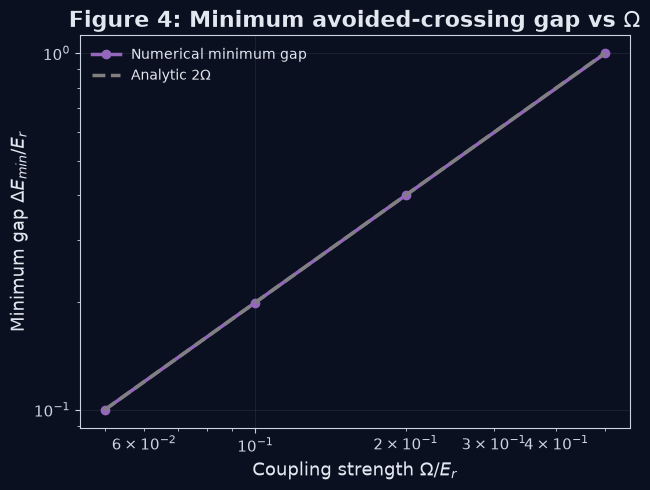

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5))

ax.loglog(omega_values, min_gaps, "o-", color="tab:purple", label="Numerical minimum gap")
ax.loglog(omega_values, [2 * o for o in omega_values], "--", color="grey", label=r"Analytic $2\Omega$")

ax.set_xlabel(r"Coupling strength $\Omega / E_r$")
ax.set_ylabel(r"Minimum gap $\Delta E_{min} / E_r$")
ax.set_title(r"Figure 4: Minimum avoided-crossing gap vs $\Omega$")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/fig4_min_gap_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()